# AP 155 Lab Exercise
---
## Exercise 2: Numbers, Subtractive Cancellation

_Instructions_: 
- **Report figure:** Two Figures (see *Problem 2: Rewriting functions...*) - Plot f(x) vs. x using the manual evaluation (the one with catastrophic cancellation) vs. the "better function". In each figure, show the area where the catastrophic cancellation occurs. There are two functions discussed in the exercise, hence two figures (Bonus: also compare with different hardware floating-point precisions: 16/32/64/128-bit)
- **Report discussion:** Two Questions: 
    - (See Problem 1) Why do the "bad" and "good" formulas of the roots give out the values they do (what makes "good" good)? What led to the difference between the obtained values?
    - (See Problem 2) In each of the two functions discussed, for which values of x does the catastrophic cancellation occur (include here what the expected values were)? How were the catastrophic cancellations remedied? 
- **Code**: Complete the codes and ensure they are functional, error-free, readable, and efficient (where needed). Include a concise markdown documentation highlighting the critical steps of your algorithm for each problem.

### Student Information
- _Full Name (Last Name, First Name)_: Iniego, Angel Nicole
- _Student No._: 2024-09622
- _Section_: THR-TX-3

### Grading Information (c/o Lab Instructor)
- [Rubrics description link](https://drive.google.com/file/d/1G9tPPcyMUag91g_R02O0wsGYPiZWy5Nn/view?usp=drive_link) (Note: percentages may still be tweaked)

| Criteria | Score | Subtotal |
| --- | --- | --- |
| Report figure | XX | 20 |
| Report discussion | XX | 20|
| Code readability | XX | 20 |
| Code efficiency | XX | 20 | 
| Code appropriateness  | XX | 20 | 
| **TOTAL** | XXX | 100 |

_Date and Time Scored (MM/DD/YYYY HH:MM AM/PM):_:_

---
## Section 1: Report

### Report figure

<img src="Figures/02_streamplot.png" alt="Streamplot" width=100% caption="Streamplot">
Figure 1. Combined Plots for Varying Difference Formulas.
<img src="Figures/02_floatComparison.png" alt="Float Comparison" width=100% caption="Float Comparison">
Figure 1. Float Comparison

### Report discussion

In this Exercise, we examine the use cases of different ways in representing numbers. The key idea being that computers can do operations fast, but not infinitely fast and that they have accuracy limits. In the first problem, we explicitly demonstrate the tendency of the computer to catastrophically cancel and present turnarounds such as multiplying by the conjugate. We got more accurate results upon imposing this method. Then, we determine the specific "breaking points" of the catastrophic cancellation. Finally, we also investigated cases where the accuracy equates to precision with the different floating types. 

### Other comments
- Learning Seaborn would be so nice.


## Section 2 (Problems and Code)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math

### Problem 1: Quadratic Equation (Gezerlis Problem 2.6)
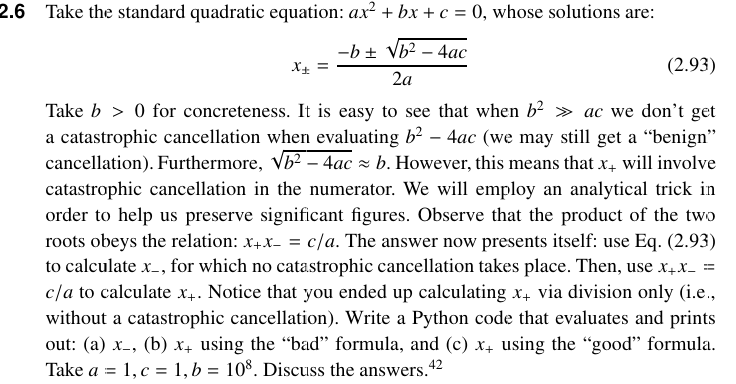

In [2]:
import numpy as np

In [3]:
def quad_xminus(a,b,c):
    return (-b-(np.sqrt(b**2 - 4*a*c)))/(2*a)

x_minus = quad_xminus(1,10**8,1)
print("The X_minus using the formula is: ",x_minus)

The X_minus using the formula is:  -100000000.0


In [4]:
def quad_xplus_bad(a,b,c):
    return (-b+(np.sqrt(b**2 - 4*a*c)))/(2*a)
    
x_plusBad = quad_xplus_bad(1,10**8,1)
print("The X_plus using the bad formula is: ",x_plusBad)

The X_plus using the bad formula is:  -7.450580596923828e-09


In [5]:
def quad_xplus_good(a,c,x_minus):
    c=1
    return c/(a*x_minus)
    
x_plusGood = quad_xplus_good(1,1,x_minus)
print("The X_plus using the good formula is: ",x_plusGood)

The X_plus using the good formula is:  -1e-08


#### Problem 1 code summary

This problem aims to solve for the root for the quadratic equation by avoiding subtraction operations. Due to the ineherent need to subtract, I instead multiplied the expression by the conjugate. The formula is simplified to c/(a*x_minus) which avoids subtraction and avoids the catastrophic cancellation. 

---


### Problem 2: Rewriting Functions to avoid subtractive cancellation

### Part 1: $ f(x) = \sqrt{x^2 + x} - x $

Consider the function 
$$ f(x) = \sqrt{x^2 + x} - x $$

- For which values of x does the catastrophic cancellation occur? 
- How can we rewrite the function to avoid catastrophic cancellation? 
- [FIGURE] Plot f(x) vs. x using the manual evaluation vs. the rewritten function. In the figure, show the area where the catastrophic cancellation occurs. (Bonus: also compare with different hardware floating-point precisions: 16/32/64/128-bit)

In [6]:
import matplotlib.pyplot as plt
import numpy as np

In [7]:
def funcGood(x):
    return x/(np.sqrt(x**2+x)+x)

def funcBad(x):
    return np.sqrt(x**2+x)-x

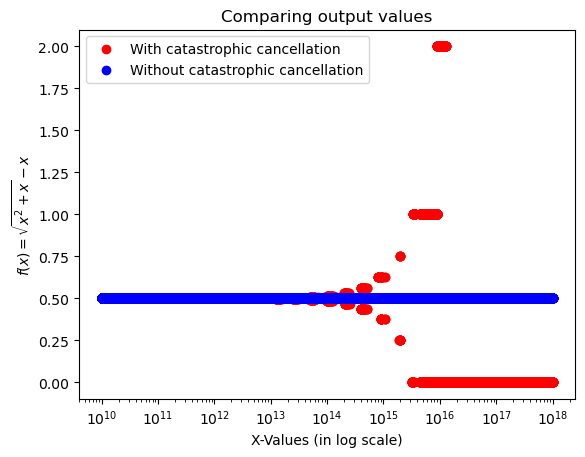

In [8]:
def funcFig1():
    a = np.logspace(10,18,100000)

    plt.figure()
    plt.xscale('log')
    plt.scatter(a, funcBad(a), color='red',
                label='With catastrophic cancellation')
    plt.scatter(a, funcGood(a), color='blue',
                label='Without catastrophic cancellation')

    plt.xlabel('X-Values (in log scale)')
    plt.ylabel(r'$f(x) = \sqrt{x^2 + x} - x$')
    plt.title("Comparing output values")
    plt.legend()

    return plt.gcf()   # get current figure

fig = funcFig1()
fig.savefig("streamplot.png")
plt.show()

In [9]:
import os
print("cwd:", os.getcwd())
print("Figures exists here?", os.path.exists("Figures"))
print("contents of cwd:", os.listdir())

cwd: /home/jovyan/AP155_TX1_1sAY2627_1/AP155_TX1_1sAY2627/Iniego
Figures exists here? True
contents of cwd: ['1IdiomPlot_INIEGO.ipynb', '0_Plotting.ipynb', 'Figures', '3HornersRule_INIEGO.ipynb', '2SubtractiveCancellation_INIEGO.ipynb', '3MoreNumbers_notes.ipynb', '1IdiomPlot_Notes-Copy1.ipynb', '.ipynb_checkpoints', 'streamplot.png']


#### Part 2: $ f(x) = \frac{e^x - 1}{x}$

Consider the function 
$$ f(x) = \frac{e^x - 1}{x}$$

- For which values of x does the catastrophic cancellation occur? 
- How can we resolve the catastrophic cancellation? 
- [FIGURE] Plot the f(x) vs. x using the manual evaluation vs. the numpy special function. In the figure, show the area where the catastrophic cancellation occurs. (Bonus: also compare with different hardware floating-point precisions: 16/32/64/128-bit)



In [10]:
def func2Good(x):
    return (np.exp(x)-1)/x

def func2Bad(x):
    return np.expm1(x)/x

/tmp/ipykernel_144694/3258827885.py:2: RuntimeWarning: invalid value encountered in divide
  return (np.exp(x)-1)/x
/tmp/ipykernel_144694/3258827885.py:5: RuntimeWarning: invalid value encountered in divide
  return np.expm1(x)/x


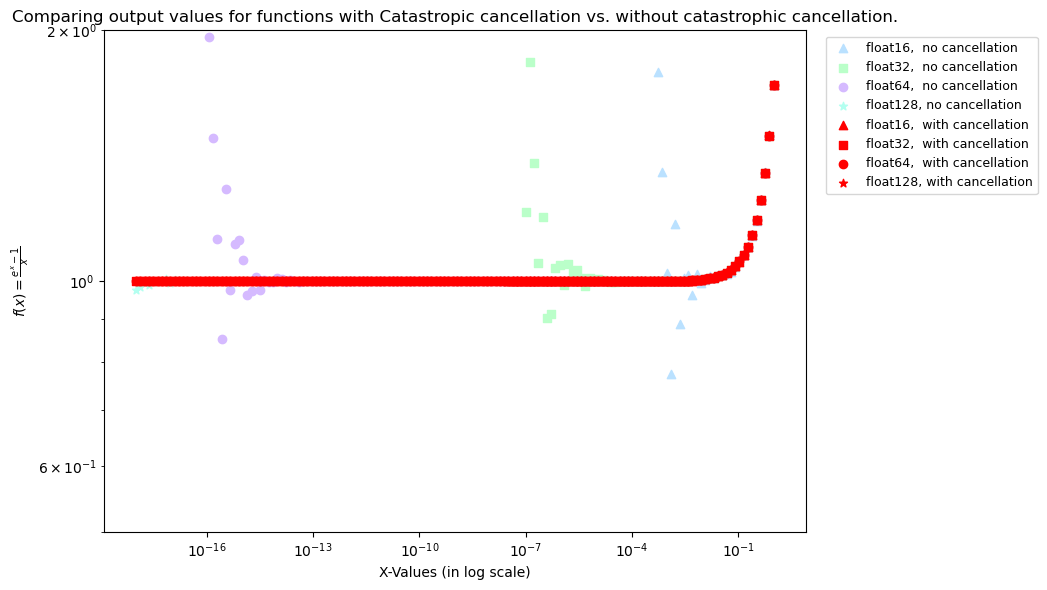

In [17]:
a = np.logspace(-18,0,150)
plt.figure(figsize=(10.6,6))
plt.scatter(a, func2Good(a.astype(np.float16)),  color='#BAE1FF', marker='^', label='float16,  no cancellation')
plt.scatter(a, func2Good(a.astype(np.float32)),  color='#BAFFC9', marker='s', label='float32,  no cancellation')
plt.scatter(a, func2Good(a.astype(np.float64)),  color='#D5BAFF', marker='o', label='float64,  no cancellation')
plt.scatter(a, func2Good(a.astype(np.float128)), color='#B3FFF0', marker='*', label='float128, no cancellation')

plt.scatter(a, func2Bad(a.astype(np.float16)),  color='red', marker='^', label='float16,  with cancellation')
plt.scatter(a, func2Bad(a.astype(np.float32)),  color='red', marker='s', label='float32,  with cancellation')
plt.scatter(a, func2Bad(a.astype(np.float64)),  color='red', marker='o', label='float64,  with cancellation')
plt.scatter(a, func2Bad(a.astype(np.float128)), color='red', marker='*', label='float128, with cancellation')
plt.xscale("log")
plt.xlabel("X-Values (in log scale)")
plt.yscale("log")
plt.ylim(0.5, 2.0)
plt.ylabel(r"$f(x) = \frac{e^x - 1}{x}$")
plt.title("Comparing output values for functions with Catastropic cancellation vs. without catastrophic cancellation.")
plt.legend(fontsize=9, loc="upper left", bbox_to_anchor=(1.02,1.0))
plt.tight_layout()
plt.savefig("floatComparison.png", dpi=300, bbox_inches="tight")
plt.show()

#### Problem 2 code summary
---
This code demonstrate consequences of catastrophic cancelling. As demonstrated in the forst problem, the limits to when the catatropic cancelling strays from the real value becomes obvious depending on the function. In this problem, the floating point accuracy. As seen in the graph, it's not in all cases when the accuracy equates to precision. 

## Section 3 (Notes)

### Floating-point representation
Python uses 64-bit float by default for any number you type in with a decimal point. Different floating point precision can be used at a lower level, which we can go around by using [Numpy dtypes](https://numpy.org/doc/stable/reference/arrays.dtypes.html). 

Useful links:
* [(Goldberg, 1991) *What every computer scientist should know about floating-point arithmetic*](https://dl.acm.org/doi/10.1145/103162.103163)
* [Wikipedia - Floating-point arithmetic](https://en.wikipedia.org/wiki/Floating-point_arithmetic)
* [Data types - NumPy](https://numpy.org/doc/stable/user/basics.types.html)
* [decimal — Decimal fixed-point and floating-point arithmetic](https://docs.python.org/3/library/decimal.html)
* [fractions — Rational numbers](https://docs.python.org/3/library/fractions.html)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

from decimal import Decimal
from fractions import Fraction

# Classic floating point quirks example
print(0.1 + 0.2)

# How about increasing precision?
print(np.float128(0.1) + np.float128(0.2))

# How bad is decreasing precision?
print(np.float16(0.1) + np.float16(0.2))

# Closest we could get to fixed-point arithmetic: decimal
print(Decimal(0.1) + Decimal(0.2))

# How about using an explicit Fraction object type?
print(float(Fraction(1, 10) + Fraction(1, 5)))